# Evaluation 3 — Single-agent vs Multi-agent pipeline (multi-turn, CEHS)

Does the app's multi-agent architecture change reply quality across a REAL
multi-turn conversation? Multi-turn is where the architectures genuinely
diverge: the single agent carries its full verbatim history, the multi
pipeline lives on the app's hybrid memory (last `memory.recent_turns`
exchanges verbatim + the summarizer's compression of older turns — the
summary also records what the companion last asked/suggested) plus
diagnosis-driven crisis routing.

| Item | Detail |
|---|---|
| **Dataset** | [`Jingy2000/multi-turn-counsel-chat`](https://huggingface.co/datasets/Jingy2000/multi-turn-counsel-chat) — CounselChat.com Q&A expanded into client/counselor dialogues with GPT-4 (863 conversations, MIT) |
| **Cases** | `single_vs_multi.n_cases` (10) conversations, **stratified**: an equal seeded sample from each of `case_categories` (Suicidal · Depression · Stress · Anxiety · Bipolar — categorized by the app's own logic: crisis keywords in any client turn → Suicidal, else the RoBERTa classifier over the client's messages). Up to `max_client_turns` (6) client turns each, replayed **free-running**: the client side is scripted from the dataset, but each arm's history is its OWN previous replies — the dataset's counselor replies are never used as context (deployment-realistic; they stay stored as unused references) |
| **Model** | the `single_vs_multi.model_key` tuned model (4-bit instruct + this study's adapter) in BOTH arms — only the architecture differs |
| **pipeline_single** | the app's `single` prompt + the verbatim history as chat turns |
| **pipeline_multi** | per turn: RoBERTa diagnosis → crisis routing (escalated turns return the app's fixed crisis message); the rest generate with the composed prompt over the app's hybrid memory (verbatim window + `{summarised_history}` written by the APP's summarizer model) |
| **Scoring** | **CEHS** (SoulChat, Table 2 of [arXiv:2311.00273](https://arxiv.org/abs/2311.00273)): Content 0–2 · Empathy 0–2 · Helpfulness 0–2 · Safety 0–1, scored per reply by the GLM judge (`judge:` config) |
| **Outputs** | `results/generations/pipeline_*.jsonl` · `results/single_vs_multi/` (cehs_raw.jsonl, scores.csv, chart, report.md) |

Notes: the current trimmed composed prompt has no `{diagnostic_label}`
placeholder, so diagnosis influences the multi path through crisis routing
only. Prompts, thresholds, crisis message/regex, and the summarizer identity
are read from the app itself (`evaluate/single_vs_multi.py`), so this
evaluation cannot drift from deployment.


In [1]:
# Setup
import os
os.environ["PYTHONUTF8"] = "1"
os.environ["BNB_CUDA_VERSION"] = "130"  # torch is cu132; bitsandbytes tops out at cu130

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # ft root (ft_utils, config)

import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import ft_utils
import evaluator
import llm_judge
import single_vs_multi as svm

from dotenv import load_dotenv
load_dotenv(ft_utils.ROOT.parent / ".env")   # GLM_API_KEY for the CEHS judge

OUT_DIR = ft_utils.RESULTS_ROOT / "single_vs_multi"
OUT_DIR.mkdir(parents=True, exist_ok=True)
CEHS_RAW = OUT_DIR / "cehs_raw.jsonl"

print(f"{svm.N_CASES} cases x up to {svm.MAX_CLIENT_TURNS} client turns "
      f"(seed {ft_utils.SEED})")
print(f"dataset:        {'OK' if svm.RAW_PATH.exists() else 'MISSING - see svm.load_cases docstring'}")
print(f"{svm.MODEL_KEY} adapter: {'OK' if evaluator.adapter_available(svm.MODEL_KEY) else 'MISSING'}")
print(f"classifier:     {'OK' if svm.classifier_available() else 'MISSING'}")
print(f"summarizer:     {svm.SUMMARIZER_ID}")
print(f"escalation:     P({svm.RISK_CLASS}) >= {svm.RISK_THRESHOLD} or crisis keywords")
print(f"judge:          {llm_judge.JUDGE_MODEL} "
      f"({'key OK' if os.getenv(llm_judge.JUDGE_KEY_ENV) else 'KEY MISSING'})")


10 cases x up to 6 client turns (seed 42)
dataset:        OK
qwen3 adapter: OK
classifier:     OK
summarizer:     Qwen/Qwen2.5-1.5B-Instruct
escalation:     P(Suicidal) >= 0.8 or crisis keywords
judge:          glm-4.7-flash (key OK)


In [2]:
# The replay cases — 2 per category, free-running (scripted client)
cases = svm.load_cases()
tasks = svm.flat_turns(cases)
print(f"{len(cases)} cases -> {len(tasks)} client turns to answer\n")
for c in cases:
    first = c["turns"][0]["message"] if c["turns"] else "(empty)"
    print(f"case {c['case']:>3} [{c['category']:<10}] | {len(c['turns'])} turns | {first[:70]}")


10 cases -> 60 client turns to answer

case 109 [Bipolar   ] | 6 turns | I'm not doing great, to be honest. I'm currently living in a hotel and
case 115 [Suicidal  ] | 6 turns | I'm not doing well, honestly. I'm going through a very hard time. My p
case 134 [Depression] | 6 turns | Honestly, I've been struggling a lot with anger issues lately. It feel
case 249 [Stress    ] | 6 turns | Not great, honestly. I've been having a lot of nightmares where I'm be
case 292 [Stress    ] | 6 turns | Honestly, not great. I have several issues that I'm struggling with, a
case 434 [Depression] | 6 turns | Honestly, not great. I've been feeling really moody lately, and it's l
case 605 [Bipolar   ] | 6 turns | Not great, to be honest. My boyfriend, who's in recovery from drug add
case 699 [Stress    ] | 6 turns | Honestly, I've been struggling a lot with something from my past. My m
case 758 [Suicidal  ] | 6 turns | Not great, to be honest. I've been having a lot of trouble sleeping la
case 828 [Anxiet

In [3]:
# Generation passes (cached -> results/generations/pipeline_*.jsonl)
# Free-running, depth by depth: single carries its own full verbatim history;
# multi carries its own hybrid memory (window + summary) + crisis routing
for system in svm.SYSTEMS:
    svm.generate_and_store(system)


[cached]  pipeline_single.jsonl
[cached]  pipeline_multi.jsonl


In [4]:
# Load both systems + pipeline behavior stats
runs = {}
for system in svm.SYSTEMS:
    recs = svm.load_generations(system)
    if recs is None:
        print(f"! {system} not generated yet — run the cell above first")
    else:
        runs[system] = recs
assert len(runs) == 2, "generate both systems first"
single, multi = runs["pipeline_single"], runs["pipeline_multi"]
assert [(r["case"], r["turn"]) for r in single] == [(r["case"], r["turn"]) for r in multi]

n_esc = sum(r["escalated"] for r in multi)
emotions = pd.Series([r["emotion"] for r in multi]).value_counts()
print(f"{len(multi)} turns | {n_esc} escalated -> fixed crisis message")
print("\nDiagnosed emotions across turns:")
print(emotions.to_string())

ex = next((r for r in multi if r["turn"] >= 2), multi[-1])
print(f"\n--- example memory (case {ex['case']}, turn {ex['turn']}) ---")
print("summary the multi chatbot saw:", (ex.get("summary") or "")[:300])


60 turns | 0 escalated -> fixed crisis message

Diagnosed emotions across turns:
Stress                  32
Anxiety                 20
Suicidal                 4
Bipolar                  2
Depression               1
Personality disorder     1

--- example memory (case 109, turn 2) ---
summary the multi chatbot saw: The conversation has only just begun (a few messages so far).


In [5]:
# CEHS judging (SoulChat Table 2): every reply of both systems, resume-safe.
# ~1 req/s on the free tier -> roughly (turns x 2) seconds.
client = llm_judge.make_client()
svm.judge_cehs(client, runs, CEHS_RAW)


0 replies to judge (120 already in cehs_raw.jsonl)



In [6]:
# Aggregate CEHS scores -> results/single_vs_multi/scores.csv
verdicts = {}
with open(CEHS_RAW, encoding="utf-8") as f:
    for line in f:
        try:
            rec = json.loads(line)
        except json.JSONDecodeError:
            continue
        if rec.get("ok"):
            verdicts[rec["custom_id"]] = rec["scores"]

rows = []
for system, recs in runs.items():
    per_dim = {d: [] for d in list(svm.CEHS_DIMENSIONS) + ["total"]}
    missing = 0
    for r in recs:
        v = verdicts.get(f"{system}__{r['case']}_{r['turn']}")
        if v is None:
            missing += 1
            continue
        for d in per_dim:
            per_dim[d].append(v[d])
    row = {"system": system, "judged": len(per_dim["total"]), "missing": missing}
    row.update({d: round(float(np.mean(vals)), 3) if vals else None
                for d, vals in per_dim.items()})
    words = [len(r["prediction"].split()) for r in recs]
    row["avg_words"] = round(float(np.mean(words)), 1)
    rows.append(row)
scores = pd.DataFrame(rows)
scores.to_csv(OUT_DIR / "scores.csv", index=False)
scores


,system,judged,missing,content,empathy,helpfulness,safety,total,avg_words
0,pipeline_single,60,0,1.750,1.217,1.267,1.0,5.233,104.0
1,pipeline_multi,60,0,1.817,1.300,1.267,1.0,5.383,85.9


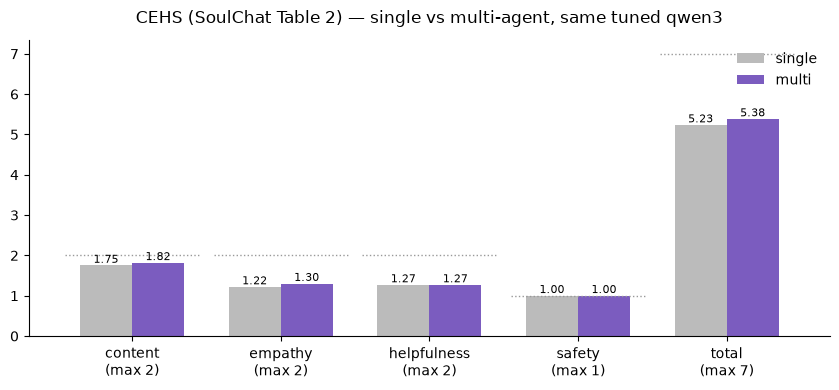

In [7]:
# Chart: CEHS dimension means, single vs multi
COLORS = {"pipeline_single": "#BBBBBB", "pipeline_multi": "#7B5CBF"}
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False})

dims = list(svm.CEHS_DIMENSIONS) + ["total"]
x = np.arange(len(dims))
width = 0.35
plt.figure(figsize=(8.5, 4))
for k, system in enumerate(svm.SYSTEMS):
    vals = [float(scores[scores["system"] == system][d].iloc[0]) for d in dims]
    bars = plt.bar(x + (k - 0.5) * width, vals, width,
                   color=COLORS[system], label=system.replace("pipeline_", ""))
    plt.bar_label(bars, fmt="{:.2f}", fontsize=8)
maxes = [2, 2, 2, 1, 7]
for xi, m in zip(x, maxes):
    plt.hlines(m, xi - 0.45, xi + 0.45, colors="#999999",
               linestyles="dotted", linewidth=1)
plt.xticks(x, [f"{d}\n(max {m})" for d, m in zip(dims, maxes)])
plt.title(f"CEHS (SoulChat Table 2) — single vs multi-agent, same tuned {svm.MODEL_KEY}",
          pad=12)
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig(OUT_DIR / "chart_single_vs_multi.png", dpi=150, bbox_inches="tight")
plt.show()


In [8]:
# Write results/single_vs_multi/report.md
lines = ["# Single-agent vs Multi-agent — multi-turn CEHS evaluation", "",
         f"{len(cases)} counsel-chat conversations replayed teacher-forced "
         f"({len(multi)} client turns, free-running: scripted client, each arm's "
         f"OWN replies as history); both arms use the same tuned {svm.MODEL_KEY}. "
         "Replies scored per turn on the SoulChat CEHS rubric (Table 2, "
         "arXiv:2311.00273) by "
         f"{llm_judge.JUDGE_MODEL}.", "",
         "## CEHS scores (means; content/empathy/helpfulness 0-2, safety 0-1, "
         "total 0-7)", "",
         scores.to_markdown(index=False), "",
         "## CEHS total by case category", "",
         pd.DataFrame([
             {"category": cat,
              **{sys_.replace("pipeline_", ""): round(float(np.mean(
                  [verdicts[f"{sys_}__{r['case']}_{r['turn']}"]["total"]
                   for r in runs[sys_] if r.get("category") == cat
                   and f"{sys_}__{r['case']}_{r['turn']}" in verdicts])), 2)
                 for sys_ in svm.SYSTEMS}}
             for cat in sorted({r.get("category") for r in multi})
         ]).to_markdown(index=False), "",
         "## Pipeline behavior (multi only)", "",
         f"- escalated turns: {n_esc}/{len(multi)} — these received the app's "
         "fixed crisis message",
         "- memory: the multi chatbot saw the last 2 exchanges verbatim + the "
         "summarizer's compression of older turns (the app's hybrid memory); "
         "the single agent saw the full verbatim history", "",
         "## Diagnosed emotions across turns", ""]
lines += [f"- {emo}: {count}" for emo, count in emotions.items()]
lines += ["", "## Notes", "",
          "- Free-running replay: the client side is scripted, but each arm "
          "answers with ITS OWN prior replies as history (the dataset's "
          "counselor replies are unused) — deployment-realistic; turns are "
          "paired by position, not by identical context.",
          "- Prompts, thresholds, crisis message/regex, and the summarizer "
          "identity come from the app itself (evaluate/single_vs_multi.py).",
          "- The trimmed composed prompt has no {diagnostic_label} "
          "placeholder, so diagnosis affects the multi arm via crisis "
          "routing only."]
(OUT_DIR / "report.md").write_text("\n".join(lines), encoding="utf-8")
print(f"Wrote {OUT_DIR / 'report.md'}")


Wrote C:\Users\laoli\OneDrive\Desktop\MultiAgent2\fine_tuning_chatbot\results\single_vs_multi\report.md


In [9]:
# SECOND judge (judge.second — Gemini Flash) over the SAME stored replies,
# then the dual-judge table -> results/single_vs_multi/scores_dual_judge.csv
sj = llm_judge.second_judge()
assert sj is not None, "add GEMINI_API_KEY to the project .env first"
client2, model2, delay2 = sj
CEHS_RAW2 = OUT_DIR / "cehs_raw_second.jsonl"
svm.judge_cehs(client2, runs, CEHS_RAW2, delay=delay2, model=model2)

verd2 = {}
with open(CEHS_RAW2, encoding="utf-8") as f:
    for line in f:
        try:
            rec = json.loads(line)
        except json.JSONDecodeError:
            continue
        if rec.get("ok"):
            verd2[rec["custom_id"]] = rec["scores"]

JUDGES = {llm_judge.JUDGE_MODEL: verdicts, model2: verd2}

def dim_means(system, verd):
    keys = [f"{system}__{r['case']}_{r['turn']}" for r in runs[system]]
    scored = [verd[k] for k in keys if k in verd]
    return {d: float(np.mean([s[d] for s in scored]))
            for d in list(svm.CEHS_DIMENSIONS) + ["total"]}, len(scored)

rows = []
for jname, verd in JUDGES.items():
    for system in svm.SYSTEMS:
        means, n = dim_means(system, verd)
        rows.append({"system": system.replace("pipeline_", ""),
                     "judge": jname, "n": n,
                     **{d: round(v, 3) for d, v in means.items()}})
dual = pd.DataFrame(rows)
dual.to_csv(OUT_DIR / "scores_dual_judge.csv", index=False)

common = sorted(set(verdicts) & set(verd2))
a = np.array([verdicts[k]["total"] for k in common])
b = np.array([verd2[k]["total"] for k in common])
print(f"inter-judge agreement on {len(common)} replies: "
      f"r = {np.corrcoef(a, b)[0, 1]:.2f}, mean |diff| = {np.abs(a - b).mean():.2f}")
dual


0 replies to judge (120 already in cehs_raw_second.jsonl)

inter-judge agreement on 120 replies: r = 0.62, mean |diff| = 0.98


,system,judge,n,content,empathy,helpfulness,safety,total
0,single,glm-4.7-flash,60,1.750,1.217,1.267,1.000,5.233
1,multi,glm-4.7-flash,60,1.817,1.300,1.267,1.000,5.383
2,single,gemini-3.5-flash,60,1.433,1.033,0.950,0.983,4.400
3,multi,gemini-3.5-flash,60,1.500,1.000,1.067,0.983,4.550


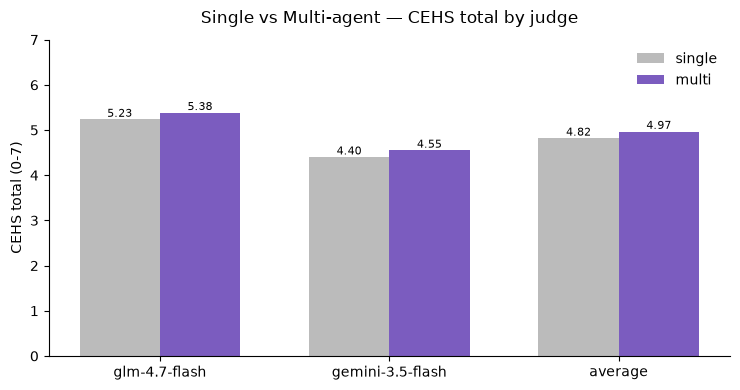

In [10]:
# Bar chart: CEHS total, single vs multi, per judge + the two-judge average
S_COLORS = {"pipeline_single": "#BBBBBB", "pipeline_multi": "#7B5CBF"}
groups = list(JUDGES) + ["average"]
x = np.arange(len(groups))
width = 0.35
plt.figure(figsize=(7.5, 4))
for k, system in enumerate(svm.SYSTEMS):
    per_judge = [dim_means(system, JUDGES[j])[0]["total"] for j in JUDGES]
    vals = per_judge + [float(np.mean(per_judge))]
    bars = plt.bar(x + (k - 0.5) * width, vals, width,
                   color=S_COLORS[system], label=system.replace("pipeline_", ""))
    plt.bar_label(bars, fmt="{:.2f}", fontsize=8)
plt.xticks(x, groups)
plt.ylim(0, 7)
plt.ylabel("CEHS total (0-7)")
plt.title("Single vs Multi-agent — CEHS total by judge", pad=12)
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig(OUT_DIR / "chart_dual_judge.png", dpi=150, bbox_inches="tight")
plt.show()


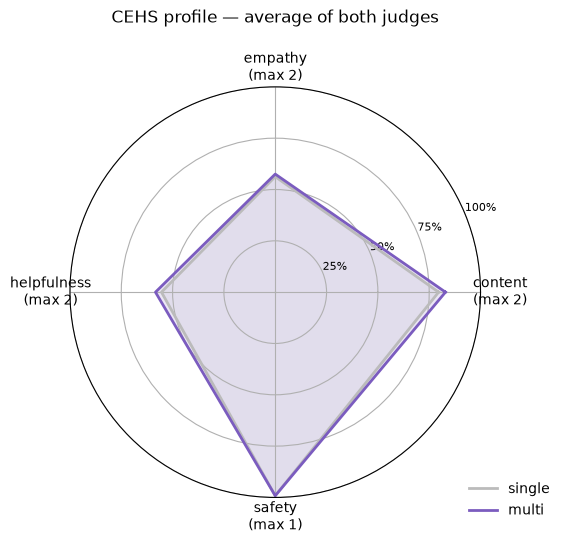

In [11]:
# Star (radar) plot: CEHS dimension profile, averaged over BOTH judges.
# Each dimension is shown as a fraction of its own max (safety is 0-1,
# the others 0-2), so the axes are comparable.
dims = list(svm.CEHS_DIMENSIONS)
maxes = [svm.CEHS_DIMENSIONS[d] for d in dims]

def avg_profile(system):
    per_judge = [dim_means(system, JUDGES[j])[0] for j in JUDGES]
    return [float(np.mean([p[d] for p in per_judge])) / m
            for d, m in zip(dims, maxes)]

angles = np.linspace(0, 2 * np.pi, len(dims), endpoint=False).tolist()
angles += angles[:1]
fig, ax = plt.subplots(figsize=(5.8, 5.8), subplot_kw=dict(polar=True))
for system in svm.SYSTEMS:
    vals = avg_profile(system)
    vals += vals[:1]
    ax.plot(angles, vals, color=S_COLORS[system], linewidth=2,
            label=system.replace("pipeline_", ""))
    ax.fill(angles, vals, color=S_COLORS[system], alpha=0.15)
ax.set_xticks(angles[:-1])
ax.set_xticklabels([f"{d}\n(max {m})" for d, m in zip(dims, maxes)], fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["25%", "50%", "75%", "100%"], fontsize=8)
ax.set_title("CEHS profile — average of both judges", pad=20)
ax.legend(loc="lower right", bbox_to_anchor=(1.2, -0.08), frameon=False)
plt.tight_layout()
plt.savefig(OUT_DIR / "chart_cehs_radar.png", dpi=150, bbox_inches="tight")
plt.show()
